In [ ]:
# pylint: disable=wrong-import-order,wrong-import-order,redefined-outer-name,invalid-name,duplicate-code
import os
from itertools import chain

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from analysis_common import shap_concentration_metrics
from IPython.display import display
from multi_sentence import DEFAULT_RUN, build_units_df

sns.set_style("whitegrid")
os.makedirs("figures", exist_ok=True)

RUN = DEFAULT_RUN
cases = ["T2T", "A2T", "I_TF_M", "I_AF_M"]
units_df = pd.concat([build_units_df(c, run=RUN) for c in cases], ignore_index=True)


def _concat_svs(items) -> np.ndarray:
    parts = [np.asarray(x, dtype=float) for x in items]
    return np.concatenate(parts) if parts else np.asarray([], dtype=float)


def _concat_tokens(items) -> list[str]:
    return list(chain.from_iterable(items))


sample_df = units_df.groupby(["run", "case", "row_index", "unit_type"], dropna=False, as_index=False).agg(
    {
        "tokens": _concat_tokens,
        "sv": _concat_svs,
        "inputs": "first",
        "count_explainable_units": "sum",
        "runtime_sec": "first",
        "n_calls": "first",
        "neyman_steps": "first",
        "input_modality": "first",
        "output_modality": "first",
        "attr_summary": "first",
        "prompt_texts": "first",
    }
)

sample_df["n_prompts"] = sample_df["prompt_texts"].apply(lambda x: len(x) if isinstance(x, list) else None)
sample_df.head()

/home/mvishiu11/Desktop/AudioShap_WUT_Bachelor/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/tmp/ipykernel_3631684/3410760026.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  units_df = pd.concat([build_units_df(c, run=RUN) for c in cases], ignore_index=True)
/tmp/ipykernel_3631684/3410760026.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when d

,run,case,row_index,unit_type,tokens,sv,inputs,count_explainable_units,runtime_sec,n_calls,neyman_steps,input_modality,output_modality,attr_summary,prompt_texts,n_prompts
0,multi_sentence_2026_01_03,A2T,0,audio,"[I, have, my, grandfather's, antique, fountain...","[0.04036581888794899, 0.011329257860779762, 0....",I have my grandfather's antique fountain pen a...,18,744.930339,1862,2,audio__male,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 1.00000...",[I have my grandfather's antique fountain pen ...,2
1,multi_sentence_2026_01_03,A2T,1,audio,"[In, terms, of, selfhood,, how, is, the, Ubunt...","[0.0354040302336216, 0.0, 0.023588743060827255...","In terms of selfhood, how is the Ubuntu philos...",13,315.171040,718,2,audio__male,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 1.00000...","[In terms of selfhood, how is the Ubuntu philo...",2
2,multi_sentence_2026_01_03,A2T,2,audio,"[On, the, basis, of, the, subject, of, the, em...","[0.05018278956413269, 0.056052688509225845, 0....","On the basis of the subject of the email, dete...",20,435.110176,1450,2,audio__male,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 1.00000...","[On the basis of the subject of the email, det...",2
3,multi_sentence_2026_01_03,A2T,3,audio,"[Give, me, a, list, of, movies,, that, have, a...","[0.06579583138227463, 0.06552444398403168, 0.0...","Give me a list of movies, that have a woman us...",14,316.092872,716,2,audio__male,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 0.99999...","[Give me a list of movies, that have a woman u...",2
4,multi_sentence_2026_01_03,A2T,4,audio,"[What, are, some, good, foods, to, eat, when, ...","[0.0436045341193676, 0.05218968167901039, 0.06...",What are some good foods to eat when you are s...,11,412.971224,1092,2,audio__male,text,"{'abs_sum_text': 0.0, 'abs_sum_audio': 0.99999...",[What are some good foods to eat when you are ...,2


count_explainable_units                                      \
                                   count   mean       std   min    25%   50%   
case   unit_type                                                               
A2T    audio                       100.0  10.17  4.735542   1.0   7.00  10.0   
I_AF_M audio                       100.0  10.17  4.735542   1.0   7.00  10.0   
       text                        100.0   8.69  3.891703   1.0   5.75   8.0   
I_TF_M audio                       100.0   7.83  3.747201   1.0   5.00   7.0   
       text                        100.0  13.26  4.887874   1.0  10.00  13.0   
T2T    text                        100.0  21.95  5.242359  10.0  18.00  22.0   

                              runtime_sec              ...              \
                    75%   max       count        mean  ...         75%   
case   unit_type                                       ...               
A2T    audio      13.00  24.0       100.0  364.937907  ...  491.934585   
I_AF_M audio      13.00  24.0       100.0  384.930607  ...  524.962169   
       text       11.00  20.0       100.0  384.930607  ...  524.962169   
I_TF_M audio      10.00  19.0       100.0  425.544568  ...  581.266058   
       text       16.00  26.0       100.0  425.544568  ...  581.266058   
T2T    text       26.25  30.0       100.0  451.095979  ...  599.259406   

                             n_calls                                     \
                         max   count     mean         std    min    25%   
case   unit_type                                                          
A2T    audio      817.372159   100.0   925.96  513.285947  120.0  533.5   
I_AF_M audio      840.075777   100.0  1003.32  533.693834  152.0  557.5   
       text       840.075777   100.0  1003.32  533.693834  152.0  557.5   
I_TF_M audio      845.751305   100.0  1085.26  520.896558  156.0  629.5   
       text       845.751305   100.0  1085.26  520.896558  156.0  629.5   
T2T    text       961.501674   100.0  1175.04  550.881496  194.0  715.5   

                                          
                     50%     75%     max  
case   unit_type                          
A2T    audio       807.0  1331.5  2014.0  
I_AF_M audio       991.0  1362.5  2010.0  
       text        991.0  1362.5  2010.0  
I_TF_M audio      1098.0  1484.0  2160.0  
       text       1098.0  1484.0  2160.0  
T2T    text       1113.0  1625.0  2170.0  

[6 rows x 24 columns]

n_prompts                                         
           count  mean       std  min  25%  50%  75%  max
case                                                     
A2T        100.0  2.18  0.411452  2.0  2.0  2.0  2.0  4.0
I_AF_M     200.0  2.18  0.410417  2.0  2.0  2.0  2.0  4.0
I_TF_M     200.0  2.18  0.410417  2.0  2.0  2.0  2.0  4.0
T2T        100.0  2.18  0.411452  2.0  2.0  2.0  2.0  4.0

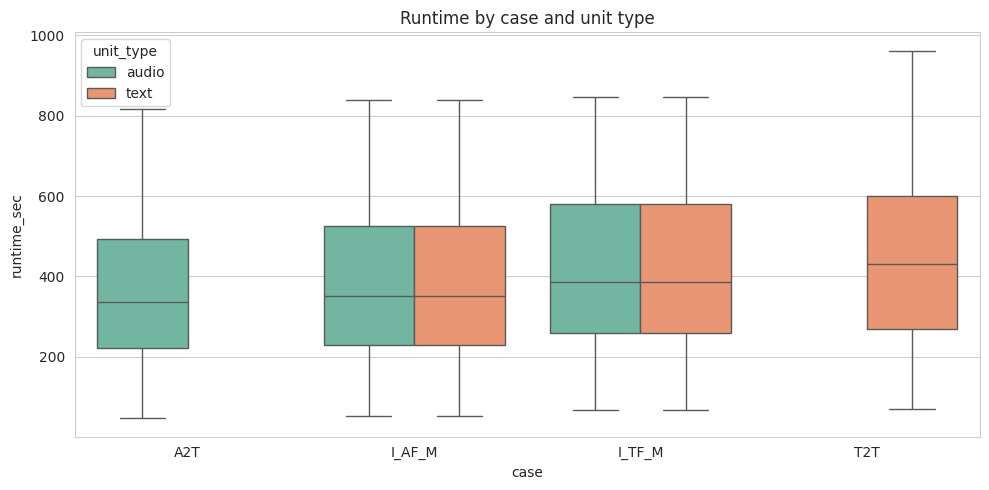

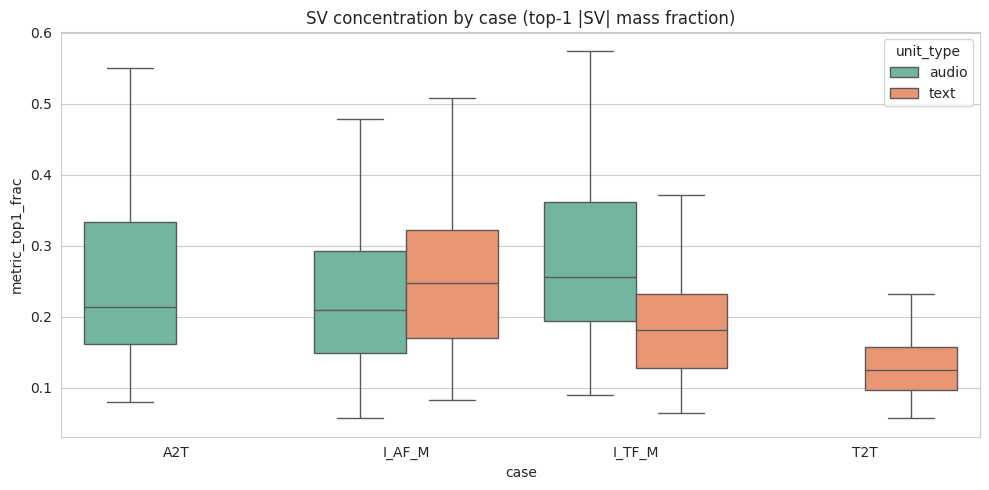

In [2]:
# Sample-level metrics
metrics = sample_df["sv"].apply(shap_concentration_metrics).apply(pd.Series)
metrics.columns = [f"metric_{c}" for c in metrics.columns]
sample_metrics_df = pd.concat([sample_df.drop(columns=["sv"]), metrics], axis=1)

display(
    sample_metrics_df.groupby(["case", "unit_type"])[["count_explainable_units", "runtime_sec", "n_calls"]].describe()
)
display(sample_metrics_df.groupby(["case"])[["n_prompts"]].describe())

plt.figure(figsize=(10, 5))
sns.boxplot(data=sample_metrics_df, x="case", y="runtime_sec", hue="unit_type", palette="Set2", showfliers=False)
plt.title("Runtime by case and unit type")
plt.tight_layout()
plt.savefig("figures/multi_sentence_runtime_by_case.png")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=sample_metrics_df, x="case", y="metric_top1_frac", hue="unit_type", palette="Set2", showfliers=False)
plt.title("SV concentration by case (top-1 |SV| mass fraction)")
plt.tight_layout()
plt.savefig("figures/multi_sentence_top1_frac_by_case.png")
plt.show()

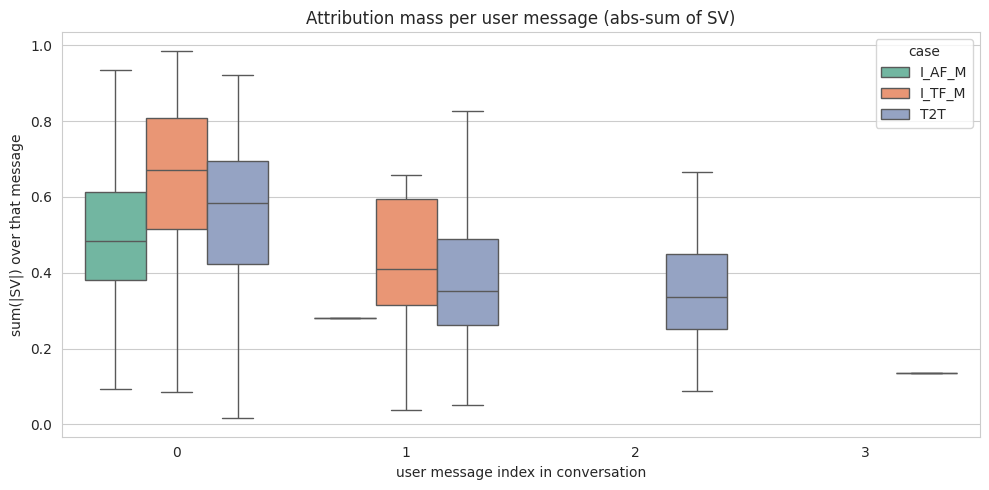

/tmp/ipykernel_3631684/1890335277.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_last_message_is_max)


,pct_last_message_has_max_abs_sum
case,
I_AF_M,1.00
I_TF_M,0.92
T2T,0.29


In [5]:
# Where does attribution land across multiple user turns?
# `units_df` keeps `turn_index` for text messages that have non-null SVs (i.e., user messages).
text_units = units_df[units_df["unit_type"] == "text"].copy()
text_units["abs_sum"] = text_units["sv"].apply(lambda x: float(np.abs(np.asarray(x, dtype=float)).sum()))
text_units["abs_max"] = text_units["sv"].apply(lambda x: float(np.abs(np.asarray(x, dtype=float)).max()))

# Rank messages within each sample in chronological order
text_units = text_units.sort_values(["case", "row_index", "turn_index", "msg_index"]).reset_index(drop=True)
text_units["message_rank"] = text_units.groupby(["case", "row_index"]).cumcount()

plt.figure(figsize=(10, 5))
sns.boxplot(data=text_units, x="message_rank", y="abs_sum", hue="case", palette="Set2", showfliers=False)
plt.title("Attribution mass per user message (abs-sum of SV)")
plt.xlabel("user message index in conversation")
plt.ylabel("sum(|SV|) over that message")
plt.tight_layout()
plt.savefig("figures/multi_sentence_abs_sum_by_message_rank.png")
plt.show()

# How often is the LAST user message the most attributed?


def _last_message_is_max(g: pd.DataFrame) -> int:
    g = g.sort_values("message_rank")
    last_abs_sum = float(g["abs_sum"].iloc[-1])
    return int(last_abs_sum >= float(g["abs_sum"].max()))


last_is_max = (
    text_units.groupby(["case", "row_index"], group_keys=False)
    .apply(_last_message_is_max)
    .groupby("case")
    .mean()
    .to_frame("pct_last_message_has_max_abs_sum")
)
display(last_is_max)